# 01 - Exploratory Data Analysis and Elo Rating Calculation

This notebook focuses on initial data exploration and the calculation of Elo ratings based on historical match data. Elo ratings will serve as a key feature for our prediction models.

In [8]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.scraper import get_past_match_results
from src.features import EloRating, calculate_elo_ratings

# Load historical match results (using dummy data for now)
# In a real scenario, you would load data from data/raw
past_results_df = get_past_match_results(start_date='2022-01-01', end_date='2026-06-15')
past_results_df['date'] = pd.to_datetime(past_results_df['date'])

print("First 5 rows of past results:")
print(past_results_df.head())

[Scraper] Gathering integrated past match results...
[Scraper] Downloading historical results from open dataset...
[Scraper] Added 4584 historical rows for training context.
[Scraper] Fetching official World Cup 2026 schedule (openfootball)...
[Scraper] Schedule loaded: 104 total matches, 23 played so far.
[Scraper] Added 16 finished official World Cup 2026 matches.
[Scraper] Total dataset compiled: 4585 matches.
First 5 rows of past results:
                             match_id       date   home_team     away_team  \
0  WC26_2022-01-01_thailand_indonesia 2022-01-01    Thailand     Indonesia   
1  WC26_2022-01-02_gabon_burkina_faso 2022-01-02       Gabon  Burkina Faso   
2      WC26_2022-01-02_sudan_zimbabwe 2022-01-02       Sudan      Zimbabwe   
3       WC26_2022-01-03_rwanda_guinea 2022-01-03      Rwanda        Guinea   
4    WC26_2022-01-04_mauritania_gabon 2022-01-04  Mauritania         Gabon   

   home_score  away_score  
0           2           2  
1           0           3  


In [9]:
# Calculate Elo ratings
elo_ratings = calculate_elo_ratings(past_results_df)

# Convert Elo ratings to a DataFrame for easier analysis
elo_df = pd.DataFrame(list(elo_ratings.items()), columns=['team', 'elo_rating'])
elo_df = elo_df.sort_values(by='elo_rating', ascending=False).reset_index(drop=True)

print("Top 10 Teams by Elo Rating:")
print(elo_df.head(10))

Top 10 Teams by Elo Rating:
          team   elo_rating
0      Morocco  1801.467342
1    Argentina  1774.267507
2        Spain  1772.496194
3      Algeria  1741.527131
4        Japan  1731.270761
5      Senegal  1720.011757
6     Portugal  1716.449256
7       France  1710.633599
8       Mexico  1707.411827
9  Ivory Coast  1704.749660


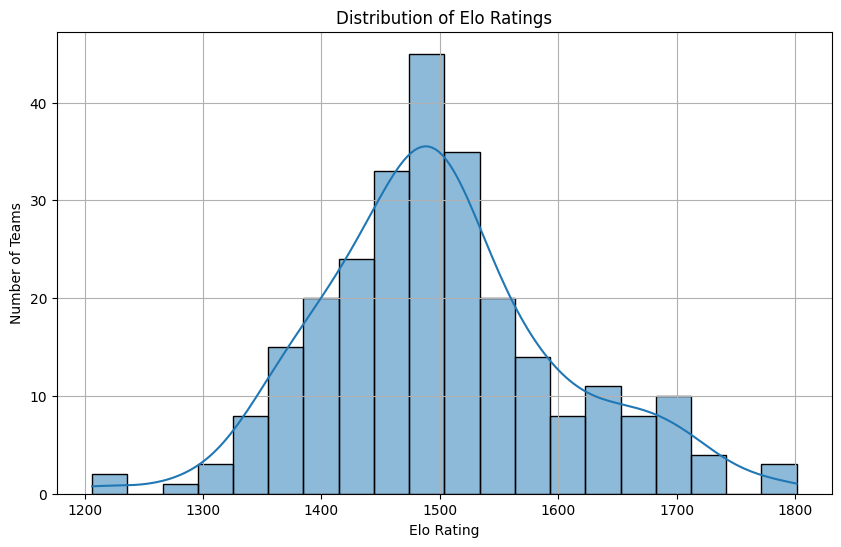

In [10]:
# Visualize Elo distribution
plt.figure(figsize=(10, 6))
sns.histplot(elo_df['elo_rating'], bins=20, kde=True)
plt.title("Distribution of Elo Ratings")
plt.xlabel("Elo Rating")
plt.ylabel("Number of Teams")
plt.grid(True)
plt.show()